In [ ]:
import laspy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
import sys

In [55]:
import laspy
import pandas as pd
import numpy as np
import nbimporter
from read_plot_voxelization import export_filtered_las, show_voxelgrid_plotly, point_cloud_to_dataframe, print_edges, plot_point_cloud_points

las_path = "../../datasource/4VOLCALC.las"
df = point_cloud_to_dataframe(las_path, True)


📂 Loading LAS/LAZ file: ../../datasource/4VOLCALC.las
Number of points: 28,456
Detected dimensions: ['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'synthetic', 'key_point', 'withheld', 'scan_angle_rank', 'user_data', 'point_source_id', 'gps_time', 'red', 'green', 'blue']
Applied LAS header scale+offset to X,Y,Z.
DataFrame created. Shape: (28456, 19)


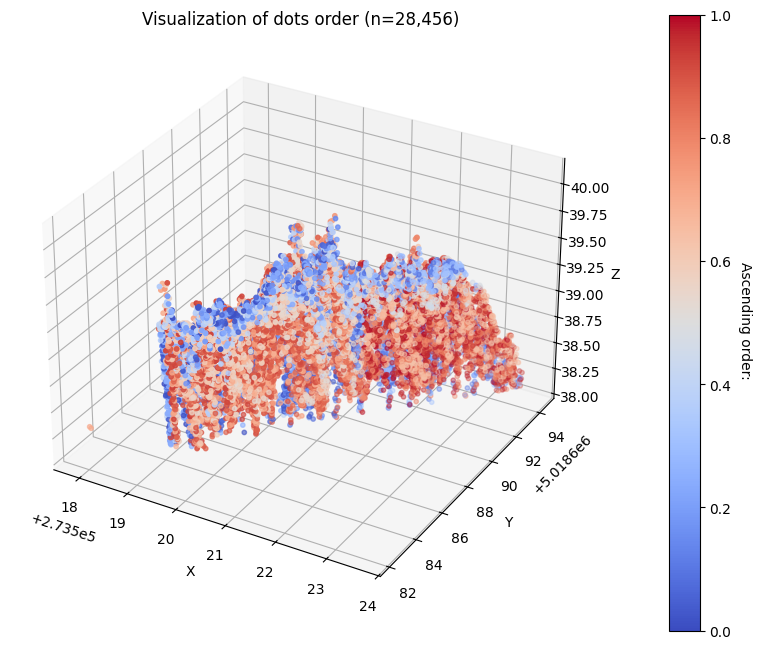

In [56]:
plot_point_cloud_points(df)

In [57]:
print_edges(df)

               X           Y      Z
min    273517.88  5018682.22  38.10
max    273523.62  5018694.34  40.09
range       5.74       12.12   1.99

Ukupna razlika po osi:
X     5.74
Y    12.12
Z     1.99
Name: range, dtype: float64


Example of exporting filtered las file

In [58]:
# filtered_df = df[df["height above ground"] > 0.5]
# output_path = "../filtered_output.las"
# las = laspy.read("../datasource/2025-07-15-Masline.las")

# new_las = export_filtered_las(filtered_df, las, output_path)

In [59]:
import laspy
import numpy as np
import open3d as o3d

def initialize_point_cloud(las_path: str, voxel_factor: float = 0.05, filter_x_min: float = 20.0):
    """
    Initializes an Open3D point cloud from a LAS file and computes basic parameters.

    Parameters
    las_path (str): Path to the LAS file.
    voxel_factor (float, optional): Voxel size factor (percentage of the point cloud’s largest dimension). Default: 0.05 (5%).
    filter_x_min (float, optional): Minimum X value for point filtering (e.g., 20). Default: 20.

    Return values

    pcd (open3d.geometry.PointCloud): Open3D point cloud object.
    voxel_size (float): Computed voxel size.
    N (int): Number of points after filtering.

    """

    # --- Loading LAS file ---
    point_cloud = laspy.read(las_path)

    # --- Filter over x ---
    if filter_x_min is not None:
        mask = point_cloud.x > filter_x_min
        point_cloud = point_cloud[mask]

    xyz = np.vstack((point_cloud.X, point_cloud.Y, point_cloud.Z)).T.astype(np.float32)

    rgb = np.vstack((point_cloud.red, point_cloud.green, point_cloud.blue)).T / 65535.0

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(xyz)
    pcd.colors = o3d.utility.Vector3dVector(rgb)

    vsize = max(pcd.get_max_bound() - pcd.get_min_bound()) * voxel_factor
    vsize = round(float(vsize), 4)

    N = np.asarray(pcd.points).shape[0]

    print(f" Point cloud read: {las_path}")
    print(f" Number of dots: {N}")
    print(f" Voxel size: {vsize} (≈ {voxel_factor*100:.1f}% max dimension)")

    return pcd, vsize, N

In [60]:
import open3d as o3d
import numpy as np

def create_voxel_grid(pcd: o3d.geometry.PointCloud, ratio: float = 0.05, verbose: bool = True):
    """
    print(f"Minimum coordinates: {np.round(min_bound,3)}")
    print(f"Maximum coordinates: {np.round(max_bound,3)}")
    print(f"Cloud dimensions (m): {np.round(dims,3)}")
    print(f"Total voxels: {len(voxel_grid.get_voxels()):,}")
    """

    if not isinstance(pcd, o3d.geometry.PointCloud):
        raise TypeError("Input must be open3d.geometry.PointCloud objekt.")

    bounds = pcd.get_max_bound() - pcd.get_min_bound()
    vsize = float(round(max(bounds) * ratio, 4))

    if verbose:
        print(f"Voxel size: {vsize:.4f} m")

    N = np.asarray(pcd.points).shape[0]
    if verbose:
        print(f"Num in original cloud: {N:,}")

    pcd_reduced = pcd.voxel_down_sample(voxel_size=vsize)
    if verbose:
        print(f"Num after downsampling: {len(pcd_reduced.points):,}")

    voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd_reduced, voxel_size=vsize)

    if verbose:
        min_bound = voxel_grid.get_min_bound()
        max_bound = voxel_grid.get_max_bound()
        dims = max_bound - min_bound


    return voxel_grid, pcd_reduced, vsize


In [61]:
pcd, voxel_size, N = initialize_point_cloud(las_path, voxel_factor=0.01)

 Point cloud read: ../../datasource/4VOLCALC.las
 Number of dots: 28456
 Voxel size: 12.12 (≈ 1.0% max dimension)


In [62]:
point_cloud = laspy.read(las_path)
if(len(df) == len(point_cloud)):
    xyz = np.vstack((df.X, df.Y, df.Z)).transpose().astype(np.float32) 
    rgb = np.vstack((point_cloud.red, point_cloud.green, point_cloud.blue)).transpose()/65535
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(xyz)
    pcd.colors = o3d.utility.Vector3dVector(rgb)



voxel_grid, pcd_reduced, vsize = create_voxel_grid(pcd, ratio=0.0005)

Voxel size: 0.0062 m
Num in original cloud: 28,456
Num after downsampling: 18,434


In [63]:
show_voxelgrid_plotly(voxel_grid, marker_size=4)

### Slicing method 

In [64]:
print(type(pcd))
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional, Callable

<class 'open3d.cpu.pybind.geometry.PointCloud'>


In [65]:
import numpy as np
from dataclasses import dataclass
from typing import Tuple, Optional, List


@dataclass
class Slice:
    """A single slice along the z-axis: z-range and points within that range."""
    zmin: float
    zmax: float
    pts:  np.ndarray  # (M, 3)

@dataclass
class BinSamples:
    """
    Samples per x-bin for one half of the slice:
    - x      : bin centers
    - ymin   : lower envelope (min y) in each bin
    - ymax   : upper envelope (max y) in each bin
    - xmin/xmax : integration domain (x boundaries)
    """
    x: np.ndarray
    ymin: np.ndarray
    ymax: np.ndarray
    xmin: float
    xmax: float

@dataclass
class FittedCurves:
    """Fitted polynomial curves (upper and lower), their degree, and domain."""
    deg_upper: int
    deg_lower: int
    coef_upper: np.ndarray   # np.polyfit coefficients (high→low)
    coef_lower: np.ndarray
    domain: Tuple[float, float]

@dataclass
class SliceDiagnostics:
    """
    Slice diagnostics: mid-z value, total slice area,
    and fitted curves for the lower and upper halves (optional).
    """
    zmid: float
    area: float
    curves_lower: Optional[FittedCurves]
    curves_upper: Optional[FittedCurves]


### Cutting over z axis


In [66]:
def slice_by_z(points: np.ndarray, n_slices: int) -> List[Slice]:
    """
    Splits the point cloud into n_slices layers of equal thickness along the z-axis.
    Returns a list of Slice objects (with z-range and points inside that range).
    """
    zmin, zmax = float(points[:, 2].min()), float(points[:, 2].max())
    edges = np.linspace(zmin, zmax, n_slices + 1)
    slices: List[Slice] = []

    for k in range(n_slices):
        # Inclusive on the left, exclusive on the right (last interval inclusive on the right)
        left, right = edges[k], edges[k + 1]
        mask = (points[:, 2] >= left) & (points[:, 2] < right if k < n_slices - 1 else points[:, 2] <= right)
        S = points[mask]
        if S.size:
            slices.append(Slice(left, right, S))
    return slices


### Splitting a slice along y and extracting x-envelopes (min/max in bins)


In [67]:
def split_slice_by_y(slice_pts: np.ndarray):
    """
    Splits slice points into lower and upper halves based on the mid y-value.
    Returns (lower_pts, upper_pts, y_mid).
    """
    y_mid = 0.5 * (slice_pts[:, 1].min() + slice_pts[:, 1].max()) #y_mid = np.median(y) more robust
    lower = slice_pts[slice_pts[:, 1] < y_mid]
    upper = slice_pts[slice_pts[:, 1] >= y_mid]
    return lower, upper, y_mid


def _envelope_by_x(pts: np.ndarray, n_bins: int) -> Optional[BinSamples]:
    """
    For the points in one slice half:
    - splits the x-domain into n_bins segments
    - finds min and max y in each bin (lower/upper envelope)
    - returns BinSamples with x-centers and corresponding ymin/ymax arrays.
    Returns None if too few valid bins exist.
    """
    if pts.shape[0] < 5 or n_bins < 3:
        return None

    x = pts[:, 0]
    y = pts[:, 1]
    xmin, xmax = float(x.min()), float(x.max())
    edges = np.linspace(xmin, xmax, n_bins + 1)
    xc = 0.5 * (edges[:-1] + edges[1:])

    ymin = np.full(n_bins, np.nan)
    ymax = np.full(n_bins, np.nan)

    for i in range(n_bins):
        # inclusive left, exclusive right (last bin inclusive right)
        left, right = edges[i], edges[i + 1]
        m = (x >= left) & (x < right if i < n_bins - 1 else x <= right)
        if np.any(m):
            yi = y[m]
            ymin[i] = yi.min()
            ymax[i] = yi.max()

    ok = ~np.isnan(ymin) & ~np.isnan(ymax)
    if ok.sum() < 4:   # too few samples for a meaningful fit
        return None

    return BinSamples(x=xc[ok], ymin=ymin[ok], ymax=ymax[ok], xmin=xmin, xmax=xmax)


### Selecting polynomial degree (2 or 3) and fitting the upper/lower curve


In [68]:
def _choose_degree(x: np.ndarray, y: np.ndarray) -> int:
    """
    Heuristic: if the smoothed signal shows at least one sign change
    in the second difference (≈ inflection), use cubic (3), otherwise quadratic (2).
    """
    if len(y) < 6:
        return 2
    k = 3  # smoothing window width
    y_pad = np.pad(y, (k, k), mode='edge')
    y_s = np.convolve(y_pad, np.ones(2 * k + 1) / (2 * k + 1), mode='valid')
    d2 = np.diff(y_s, n=2)
    sign = np.sign(d2)
    sign[sign == 0] = 1
    flips = np.sum(sign[:-1] * sign[1:] < 0)
    return 3 if flips >= 1 else 2


def fit_upper_lower(bin_samp: BinSamples) -> FittedCurves:
    """
    Fits two polynomial curves along x: upper (from ymax) and lower (from ymin),
    with automatic degree selection (2 or 3).
    """
    xu = bin_samp.x
    yl = bin_samp.ymin
    yu = bin_samp.ymax

    deg_u = _choose_degree(xu, yu)
    deg_l = _choose_degree(xu, yl)

    cu = np.polyfit(xu, yu, deg_u)
    cl = np.polyfit(xu, yl, deg_l)

    return FittedCurves(
        deg_upper=deg_u, deg_lower=deg_l,
        coef_upper=cu, coef_lower=cl,
        domain=(bin_samp.xmin, bin_samp.xmax),
    )


### Slice area = ∫(upper − lower) dx (exact integral of the polynomials)


In [69]:
def area_between_polys(curves: FittedCurves) -> float:
    """
    Analytical integral of the difference between the two polynomials on [xmin, xmax]:
    A = ∫ (f_upper - f_lower) dx
    """
    xmin, xmax = curves.domain
    Pu = np.poly1d(curves.coef_upper)
    Pl = np.poly1d(curves.coef_lower)
    Pint = np.polyint(Pu - Pl)
    return float(Pint(xmax) - Pint(xmin))


### Slice area (sum of lower + upper halves) + diagnostics


In [70]:
def slice_area_from_points(slice_pts: np.ndarray, n_bins: int):
    """
    Computes the slice area as the sum of the areas of its two halves (split along y):
    - obtains x-envelopes (ymin/ymax) for each half,
    - fits polynomial curves and integrates them.
    Returns (area_total, SliceDiagnostics).
    """
    lower, upper, _ = split_slice_by_y(slice_pts)
    diag_lower = diag_upper = None
    area_total = 0.0

    for half_pts, name in ((lower, "lower"), (upper, "upper")):
        bins = _envelope_by_x(half_pts, n_bins=n_bins)
        if bins is None:
            continue
        curves = fit_upper_lower(bins)
        area = area_between_polys(curves)
        area_total += area
        if name == "lower":
            diag_lower = curves
        else:
            diag_upper = curves

    zmid = 0.5 * (slice_pts[:, 2].min() + slice_pts[:, 2].max())

    return area_total, SliceDiagnostics(
        zmid=zmid, area=area_total,
        curves_lower=diag_lower, curves_upper=diag_upper
    )


### Main function: volume = sum A(z_k) * Δz


In [71]:
def estimate_volume(points: np.ndarray, n_slices: int = 50, n_bins: int = 40):
    """
    Main volume algorithm:
      1) split the point cloud into n_slices along the z-axis
      2) compute the area of each slice (lower + upper half)
      3) volume = sum(area * slice thickness Δz)
    Returns (V, diag) where diag is a dict with: z_mid, areas, dz.
    """
    slices = slice_by_z(points, n_slices=n_slices)

    A, Z, dzs = [], [], []
    for s in slices:
        area, diag = slice_area_from_points(s.pts, n_bins=n_bins)
        dz = s.zmax - s.zmin
        A.append(area)
        Z.append(diag.zmid)
        dzs.append(dz)

    A = np.array(A, dtype=float)
    dzs = np.array(dzs, dtype=float)
    V = float(np.sum(A * dzs))

    return V, {"z_mid": np.array(Z), "areas": A, "dz": dzs}


In [72]:
pts = np.asarray(pcd.points) 
V, diag = estimate_volume(pts, n_slices=60, n_bins=50)
print("Approximate volume:", V)

Approximate volume: 4.571497670933605


/tmp/ipykernel_14484/3344451377.py:30: RankWarning:

Polyfit may be poorly conditioned

/tmp/ipykernel_14484/3344451377.py:31: RankWarning:

Polyfit may be poorly conditioned

/tmp/ipykernel_14484/3344451377.py:30: RankWarning:

Polyfit may be poorly conditioned

/tmp/ipykernel_14484/3344451377.py:31: RankWarning:

Polyfit may be poorly conditioned

/tmp/ipykernel_14484/3344451377.py:30: RankWarning:

Polyfit may be poorly conditioned

/tmp/ipykernel_14484/3344451377.py:31: RankWarning:

Polyfit may be poorly conditioned

/tmp/ipykernel_14484/3344451377.py:30: RankWarning:

Polyfit may be poorly conditioned

/tmp/ipykernel_14484/3344451377.py:31: RankWarning:

Polyfit may be poorly conditioned

/tmp/ipykernel_14484/3344451377.py:30: RankWarning:

Polyfit may be poorly conditioned

/tmp/ipykernel_14484/3344451377.py:31: RankWarning:

Polyfit may be poorly conditioned

/tmp/ipykernel_14484/3344451377.py:30: RankWarning:

Polyfit may be poorly conditioned

/tmp/ipykernel_14484/3344451377.

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

def plot_slice_and_fits(
    slice_pts: np.ndarray,
    n_bins: int = 40,
    title: str | None = None,
    local_coords: bool = True,
    show_fill: bool = True,
):
    if slice_pts.ndim != 2 or slice_pts.shape[1] != 3:
        raise ValueError("slice_pts mora biti oblika (M,3).")

    m = np.isfinite(slice_pts).all(axis=1)
    pts = slice_pts[m]
    if pts.shape[0] == 0:
        raise ValueError("Nema valjanih (finite) točaka u slice_pts.")

    # offset iz ISTOG skupa (pts)
    x0 = float(pts[:, 0].min())
    y0 = float(pts[:, 1].min())

    pts_loc = pts.copy()
    if local_coords:
        pts_loc[:, 0] -= x0
        pts_loc[:, 1] -= y0

    # split radi na istim koordinatama koje plotamo i fitamo (pts_loc)
    lower, upper, ymid = split_slice_by_y(pts_loc)

    fig, ax = plt.subplots(figsize=(9, 5))

    # slice points - vidljivo i iznad fill-a
    ax.scatter(
        pts_loc[:, 0], pts_loc[:, 1],
        s=8, alpha=0.25, marker='.',
        zorder=10, rasterized=True,
        label=f"slice points ({len(pts_loc):,})"
    )

    def _draw_half(half_pts: np.ndarray, half_label: str):
        bins = _envelope_by_x(half_pts, n_bins=n_bins)
        if bins is None:
            ax.text(0.02, 0.95 if half_label == "upper" else 0.90,
                    f"Not enough samples for {half_label} half",
                    transform=ax.transAxes, fontsize=9, ha="left", va="top")
            return

        curves = fit_upper_lower(bins)
        xf = np.linspace(curves.domain[0], curves.domain[1], 400)

        Pu = np.poly1d(curves.coef_upper)
        Pl = np.poly1d(curves.coef_lower)
        yu = Pu(xf)
        yl = Pl(xf)

        ax.plot(bins.x, bins.ymax, "o", ms=3.5, zorder=20, label=f"{half_label}: envelope ymax")
        ax.plot(bins.x, bins.ymin, "o", ms=3.5, zorder=20, label=f"{half_label}: envelope ymin")

        ax.plot(xf, yu, lw=2.2, zorder=30, label=f"{half_label}: upper curve (deg {curves.deg_upper})")
        ax.plot(xf, yl, lw=2.2, zorder=30, label=f"{half_label}: lower curve (deg {curves.deg_lower})")

        if show_fill:
            ax.fill_between(xf, yl, yu, alpha=0.06, zorder=2)

    _draw_half(lower, "lower")
    _draw_half(upper, "upper")

    ax.axhline(ymid, ls="--", lw=1.2, zorder=5, label="y mid")

    ax.set_xlabel("x [m]" + (" (local)" if local_coords else ""))
    ax.set_ylabel("y [m]" + (" (local)" if local_coords else ""))

    if title:
        if local_coords:
            ax.set_title(f"{title}  (offset: x0={x0:.2f}, y0={y0:.2f})")
        else:
            ax.set_title(title)

    if not local_coords:
        ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=True))
        ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=True))

    ax.grid(True, alpha=0.25)

    # legenda van grafa
    handles, labels = ax.get_legend_handles_labels()
    uniq = {}
    for h, l in zip(handles, labels):
        if l not in uniq:
            uniq[l] = h
    ax.legend(uniq.values(), uniq.keys(), loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)

    plt.tight_layout()
    plt.show()


426


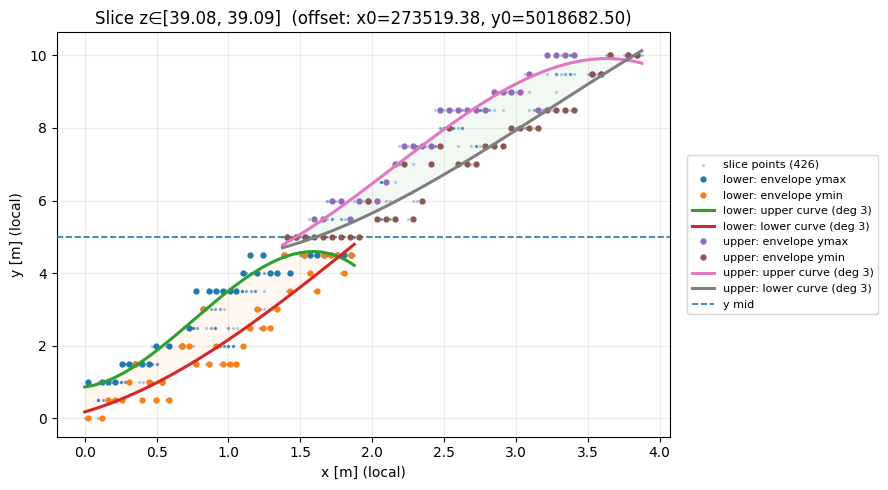

426
99


In [74]:
slices = slice_by_z(pts, n_slices=100)
mid = slices[len(slices)//2]
print(len(mid.pts))
plot_slice_and_fits(mid.pts, n_bins=40, title=f"Slice z∈[{mid.zmin:.2f}, {mid.zmax:.2f}]")
print(len(mid.pts))
print(len(slices))

pts: 28456


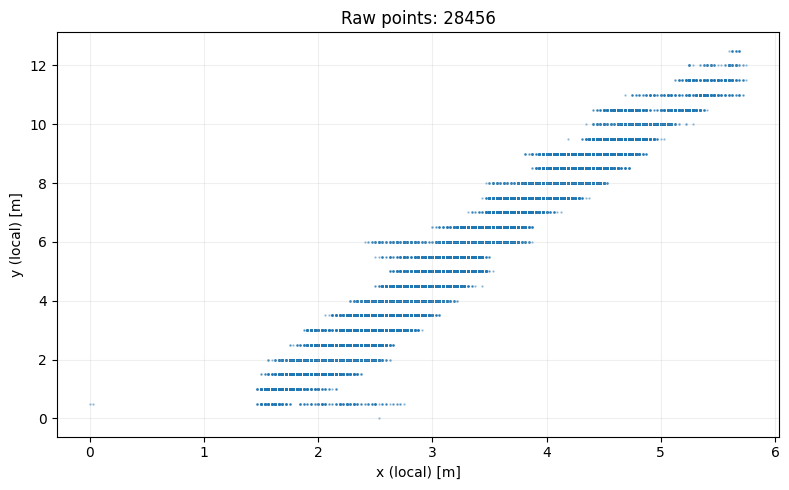

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# mid = slices[len(slices)//2]
xy = pts[:, :2]   # uzmi samo X,Y

print("pts:", len(pts))

# (opcionalno) lokalne koordinate da se ne vrte 1e6 brojevi
xy_local = xy - xy.min(axis=0)

plt.figure(figsize=(8,5))
plt.scatter(xy_local[:,0], xy_local[:,1], s=2, alpha=0.4, marker='.', rasterized=True)
plt.title(f"Raw points: {len(pts)}")
plt.xlabel("x (local) [m]")
plt.ylabel("y (local) [m]")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
